# Notebook 3: Error Mitigation (Zero noise extrapolation)

> This notebook is the 4th notebook of this series. From previous notebooks, you learned a general understanding about quantum computing, how to use AWS for infrastructure, and error suppression. In this notebook, you will pick up the concepts and applications of the error mitigation for quantum information. Both concepts and examples will be provided in the context for a better understanding.
>
> This notebook is organized as follows: Firstly, we introduce the concepts of quantum error mitigation and extrapolation. Then, we provide an example of using different extrapolation methods for error mitigation. In the end of this notebook, we provide an example of using AWS Batch for zero-noise extrapolation. This is an example of integrating the infrastucture to speed up the simulations. 

## 1. Motivation: Why do we need Quantum error mitigation, and what is it? 
Current generation of quantum computers and quantum circuits are still limited by finite scales, high noise, short coherence time and high error rate, also known as noisy intermediate-scale quantum (NISQ) devices. Operation errors from current devices still make precise quantum computation challenging. On the hardware side, some techniques can be implemented via quantum control to suppress errors of quantum circuits, like dynamical decoupling introduced in the previous notebook.  Beyond this, one natural question for readers may be: what else can we do for more precise outcomes from our improved but imperfect quantum devices?    

It is where quantum error mitigation [1] comes in. Quantum error mitigation is to apply post-processing on the data acquired from the same noisy quantum devices to reduce the bias induced by noises. An analog classical example for this is: Let’s assume you implement the same measurement on $x_0$ and get the outcome $f_{meas}(x_0)$. To improve this result, we take extra measurements with the same devices on $x_0,x_1,x_2,...$ and fit the output $f_{meas}(x_0),f_{meas}(x_1),f_{meas}(x_2),...$ In general, the fitting result $f_{fit}(x_0)$ gives a better estimation and is more closed to the unbiased result $f_{reality}(x_0)$. 




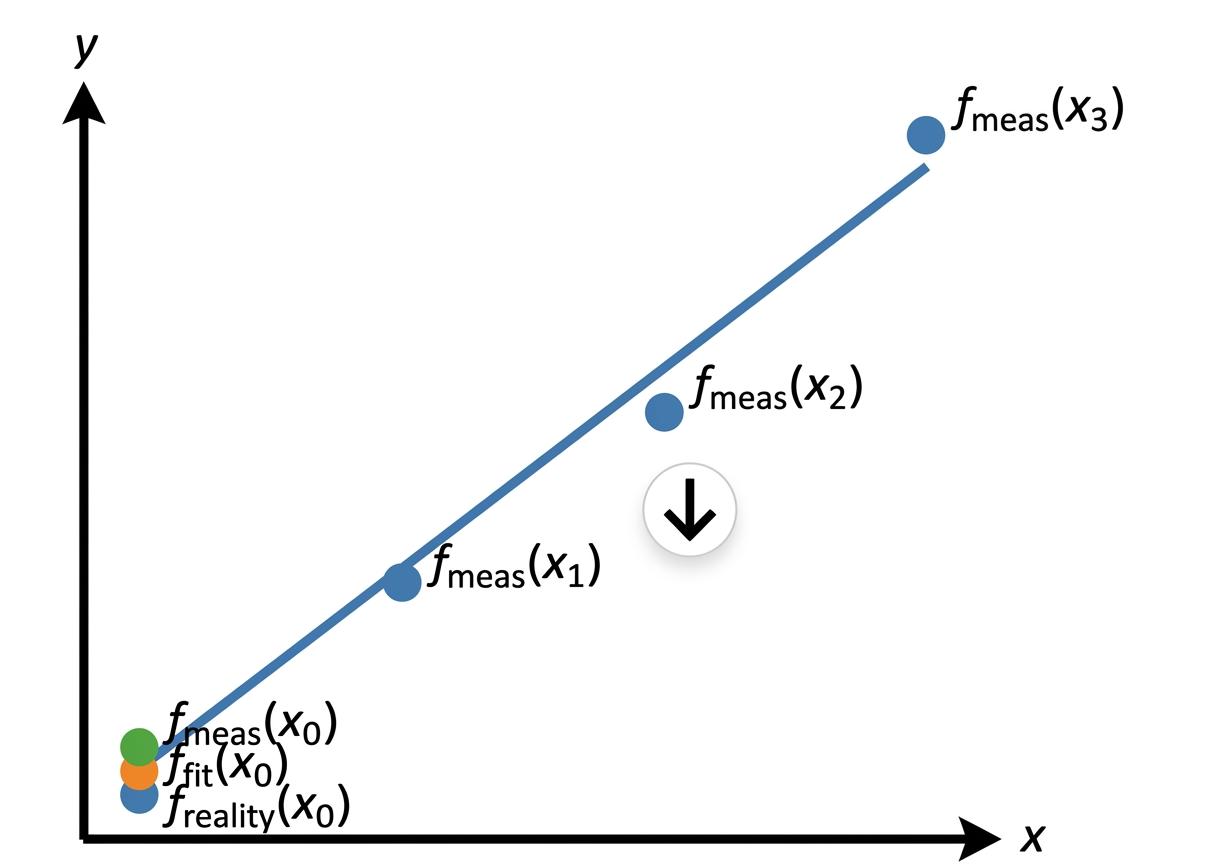

In [1]:
from IPython.display import Image, display

display(Image(filename="figures/notebooks/plot_nb3_1.png",width = 400))

## 2. What is Zero-noise extrapolation (ZNE)? 

There are various methods of quantum error mitigation. Each of them requires different resources and aims for reducing different types of noises, and it is better to leave references here for interested readers to explore [1,2]. In this notebook, we are going to introduce one of the most prevailing methods, zero-noise extrapolation (ZNE): the strategy is to implement the circuits with a series of scaling error rates, and extrapolate the outcome of the zero-error circuit based on the measurements with controlled error rates. 

The advantages of implementing ZNE is its simplicity and generality. The concept is straightforward. It works on any quantum circuits. Users can implement this method without any prior knowledge of hardware and error sources, as long as they can scale the errors and implement extra runs to the circuits.

Note that different extrapolation approaches and methods to amplify noises lead to different results, so we should not consider each kind of ZNE approach as a general method for all kinds of noises. 



## 3. Examples of Zero-noise extraploation implementation

In the following, we give an example of Zero-noise implementaion. We will install Mitiq -- an extended python package helps for constructing circuits first. Then, we will build up a noisy quantum circuits for simulating **Ising model**. The measurement outcomes of the circuits -- with different scale factors -- will be used for extrapolation to estimate the outcomes of circuits without noises.   

### 3.0 Cost tracking

Amazon Braket can estimate the cost of quantum tasks created from this notebook. The tracker starts here, so later QPU tasks are included in the estimate printed near the end of the notebook.

In [ ]:
from braket.tracking import Tracker

t = Tracker().start()

### 3.1 Installing Mitiq

>mitiq is not included by default with `amazon-braket-examples` requirements or in the Amazon Braket Notebook Instances. To install, uncomment the first line in the next code block, and restart the notebook. Or run install from `extra/requirement-mitiq.txt`. 

Mitiq utilizes Cirq as the backend, and may represent circuits using their representation. We will use it later for circuit construction.

In [1]:
# %pip install mitiq cirq-ionq
try:
    import mitiq  # noqa: F401
    print("Package 'mitiq' is installed.")
except ImportError:
    print("!! Package 'mitiq' is not installed !!")

Package 'mitiq' is installed.


In [2]:
import sys
sys.path.append("helper_functions")   # relative path from notebook to import functions

from functions import rzz_angle, ising_1d, fit_exp_linearized

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import time

from mitiq.zne import construct_circuits

from braket.circuits import Circuit
from braket.circuits.observables import Z
from braket.devices import LocalSimulator
from braket.emulation.local_emulator import LocalEmulator

np.set_printoptions(linewidth=400,precision=3,suppress=True)
warnings.filterwarnings("ignore", category=UserWarning, module="qiskit_braket_provider")

# here we will use the noise from a device emulator 

with open("error_reduction/emerald_properties_251106.json","r") as fp:
    props = json.load(fp)

emulator = LocalEmulator.from_json(props)
qd = LocalSimulator("braket_dm",noise_model= emulator._noise_model)

### 3.2 Define the parameters of the circuits:

**Ising model** is a model for describing ferromagnetism or statistical mechanics. Here we consider the simplest one: 1-Dimensional spin chain. Each spin interacts with its nearest neighboring spins to exchange spins or flips the spin on its own (called self-interaction). We defined the parameters for describing the interaction strength as  `@self_interaction` and `@hoppings`.

The number of spins in the circuit is defined as `@num_qubits`. In the following simulations, we will simulate the spin chain evolves over time. It evolves over discrete time steps, and the number of the discrete time steps are defined as `@num_steps`. The number of repeated runs for simulating this model is defined as `@num_shots`.

Based on these parameters, the `@time_step` is the circuit to evolve the whole system for each discrete step. To evolve the circuit over multiple time steps, we only need to cascade `@time_step` circuits repeatedly.

<div class="alert alert-block alert-success">
<b>Activity:</b> Change the parameters in the cell below for the simulation.
</div>

In [3]:
num_shots = 10000
num_qubits = 8
num_steps = 10

# qubit_labels = [3,9,17,25,33,41,47,48,52][:num_qubits]
self_interaction = 0.2
hoppings         = 0.05

time_step = ising_1d(0.2,0.05, num_qubits)

### 3.3 Construct circuits 
Here we see a standard 1-d transverse field Ising model circuit. Now we can get ideal expectation values and visualize them. 

In [4]:
print('Calculating ideal evolutions...')
qd_exact = LocalSimulator()
obs = Circuit()

for i in range(num_qubits):
    obs.expectation(Z(i))

circ = Circuit()
ideal_evs = []
for steps in range(num_steps):
    circ+= time_step 
    res = qd_exact.run(circ + obs, shots = 0).result()
    ideal_evs.append(res.values)

dat = np.array(ideal_evs)


Calculating ideal evolutions...


Text(0, 0.5, 'Local Z_i Populations')

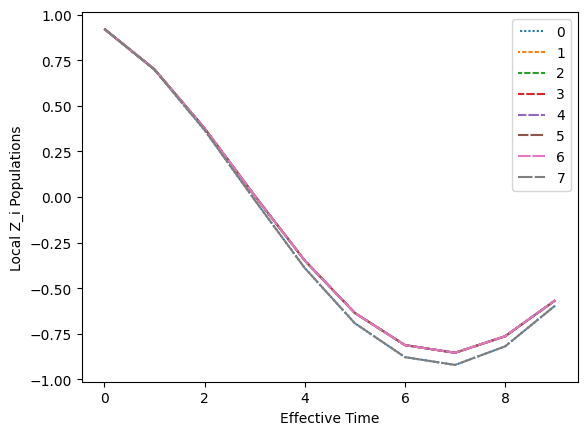

In [5]:
for i in range(num_qubits):
    plt.plot(range(num_steps), dat[:,i], label = f'{i}', linestyle = (1,(i+1,1)))
plt.legend()
plt.xlabel("Effective Time")
plt.ylabel("Local Z_i Populations")

#### Intepretation:

In this regime we see oscillatory behavior that is pretty consistent across local sites.  

Below, we calculate the results when the noise is included and compare it to the ideal case.

In [6]:
print('Calculating noisy results...')

noisy_circ = Circuit()
noisy_evs = []
start_time = time.perf_counter()
for step in range(num_steps):
    noisy_circ+= time_step 
    print(f'Running step: {step}')

    res = qd.run(noisy_circ, shots = num_shots).result()
    ## the *(-2)+1 is to turn 0 and 1 basis to +1 and -1 spin 
    noisy_evs.append(np.mean(res.measurements*(-2)+1, axis=0))
print('Done!')
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Function executed in: {execution_time:.6f} seconds")

noisy_evs = np.array(noisy_evs)

Calculating noisy results...
Running step: 0
Running step: 1
Running step: 2
Running step: 3
Running step: 4
Running step: 5
Running step: 6
Running step: 7
Running step: 8
Running step: 9
Done!
Function executed in: 7.315456 seconds


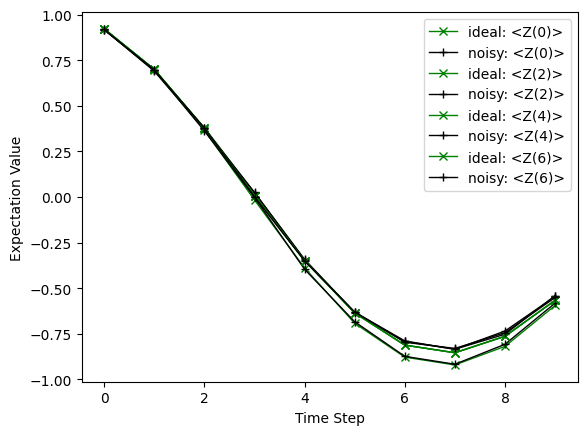

In [7]:
for i in range(0,num_qubits,2):
    plt.plot(range(num_steps), dat[:,i], marker='x',linewidth=1, c = 'g',
                label=f"ideal: <Z({i})>"
                )
    plt.plot(range(0,len(noisy_evs)), noisy_evs[:,i], marker='+',c='k',linewidth=1,
                label=f"noisy: <Z({i})>")
plt.xlabel("Time Step")
plt.ylabel("Expectation Value")
plt.legend()

#### Intepretation:

The black lines above represent the results from the noisy circuits. We plot out some of the qubits as a demonstration. We still see oscillatory behavior as the ideal case (green lines) but deviated from the ideal case. The discrepancies are due to the noise.

### 3.4 Running the circuits for ZNE -- scale up the circuits

Now, to compare, we will run our ZNE procedure. Note, here the `scale_factors` represents the noise amplification levels we will perform, which means randomly picks some quantum gates $U$ in the circuit and adds extra pairs $U^{\dagger}U$ next to it to make the total gate numbers on each qubit scaled by `scale_factors`. We will use the default strategies but Mitiq allows you to explore various [folding options](https://mitiq.readthedocs.io/en/stable/guide/zne-3-options.html) for integer and non-integer powers. 

Additionally, to look at the extrapolations, we will use the `construct_circuits`pattern, as opposed to the 1-shot Executor based approach seen in the first notebook. We can still use an Executor, as we just need an expectation value, but we will not automate the entire process. 

The expectation value of each circuit -- each qubit at each time step -- is stored in `@zne_evs`. We will use these data to perform noise extrapolation later.  

We also track on the time for simulations because we plan to speed up the simulation with AWS Batch.

In [8]:
scale_factors = [1.0, 2.0, 3.0]
zne_forloop_time = []
circ=  Circuit()
zne_evs = np.zeros((num_steps,len(scale_factors),num_qubits))

start_time = time.perf_counter()

for step in range(num_steps):
    circ += time_step 
    circuits = construct_circuits(circ, scale_factors)
    #plot the circuits
    print(f'Running step: {step}')
    for j,item in enumerate(circuits):
        start_time2 = time.perf_counter()
        print(f'  - subcircuit {j}')
        res = qd.run(item, shots = num_shots).result()
        zne_evs[step,j,:] = np.mean(res.measurements*(-2)+1, axis=0)
    end_time2 = time.perf_counter()
    execution_time = end_time2 - start_time2
    zne_forloop_time.append(execution_time)
    print(f"Function executed in: {execution_time:.6f} seconds")
print('Done!')
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Function executed in: {execution_time:.6f} seconds")
zne_forloop_time = np.array(zne_forloop_time)

Running step: 0
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 0.223838 seconds
Running step: 1
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 0.371724 seconds
Running step: 2
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 0.523021 seconds
Running step: 3
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 0.680607 seconds
Running step: 4
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 0.838220 seconds
Running step: 5
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 0.977827 seconds
Running step: 6
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 1.110998 seconds
Running step: 7
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 1.567422 seconds
Running step: 8
  - subcircuit 0
  - subcircuit 1
  - subcircuit 2
Function executed in: 1.699333 seconds
Running step: 9
  - subcircuit 0
  - subcircui

## 4. Extrapolation methods 

We have the results stored in `@zne_evs`, we will go through different ways of extrapolation to retrieve the ZNE outcomes.

**Richardson extrapolation**:

As mentioned before, there are many methods for extrapolations, like polynomial, exponential extrapolation [4]. One of the most common ZNE approaches is Richardson extrapolation for its simplicity in theory and general lower bias. The idea of Richardson extrapolation is to sample the measurement outcomes $f(x)$ at $(n+1)$ different noise parameters $\lambda_1, …, \lambda_n$, with a $n-$polynomial noise fitting $f(\lambda) = f(0)+ a_1 \lambda + a_2 \lambda^2 +...a_n \lambda^n $. The trick is to utilize a set of linear combination coefficient $c_1,...c_n$ to construct 
$f(0) = \Sigma^{n}_{i=1} c_i f(\lambda_i)$. $f(0)$ can be acquired through cancelling the errors via coefficient $c_1,...c_n$ choosing. 

Of course, each extrapolation makes different assumptions on the noise models, and thus the performance and the computational resource requirement also vary by conditions. Readers can imagine that the qubit number, circuit depths, and noise on quantum devices can influence the extrapolation results. Most importantly, the cost (can be the budget for access to AWS or the number of shots) determines the computational resources limit for extrapolation. Therefore, in practical implementations, users should take all of them into account to acquire the optimal extrapolation results. Some inspiring references for optimization are included in the ref [3,4,5].  

For each qubit at each time step, we fit the outcome with a quadratic polynomial $f(\lambda) = a\lambda^2+b\lambda+c$ with scale_factors $\lambda= 1,2,3$ since we only have three data points. np.polyfit is a usual way to fit the values with polynomial functions. 
The constant coefficient $c$ is therefore the zero-noise result acquired from the extrapolation.  

**Linear extrapolation**: 

It is a simpler model: Assuming the noise is linear to the scale factors and fit the data as $f(\lambda) = a + b\lambda$.



**Exponential extrapolation**: 

Exponential extrapolation tries to fit an exponential curve to the data of the form $f(\lambda) = a + be^{(-c\lambda)}$, with $c > 0$. Notably, we can also incorporate the infinite limit, which effectively sets $a$, and then allows for a linear regression of the form $log(f(\lambda)) = log(b) - c\lambda$. Here, we assume that f($\infty$)$\rightarrow 0$, and thus a = 0. 
In the following section, readers will go through the examples for the ZNE demonstration.


In [9]:
extrapolated_richard = np.zeros((num_steps,num_qubits))
extrapolated_linear = np.zeros((num_steps,num_qubits))
extrapolated_exp = np.zeros((num_steps,num_qubits))
for i in range(num_steps):
    for j in range(num_qubits):
        coeff = np.polyfit(scale_factors, zne_evs[i,:,j].tolist(), len(scale_factors)-1)
        extrapolated_richard[i,j] = coeff[-1]
for i in range(num_steps):
    for j in range(num_qubits):
        coeff = np.polyfit(scale_factors, zne_evs[i,:,j].tolist(), 1)
        extrapolated_linear[i,j] = coeff[-1]
for i in range(num_steps):
    for j in range(num_qubits):
        coeff = fit_exp_linearized(np.array(scale_factors), zne_evs[i,:,j] , 0)
        extrapolated_exp[i,j] = coeff[0]

### 4.1 Extrapolation results comparing to the ideal value

The figure below is to compare the extrapolation outcome from different methods to the ideal value (black line) and the value acquired from the noisy circuits.

Let's take a look at the qubit0 at #3 times step. We plot out the fitting function and the data points acquired. 

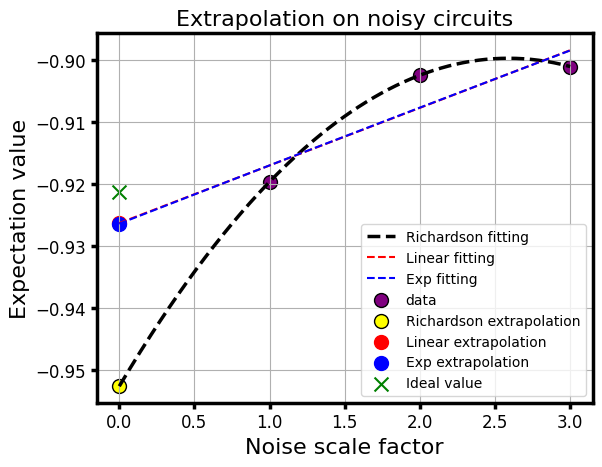

In [48]:
qubit_index = 0
step_index = 7
coeff_Richard = np.polyfit(scale_factors, zne_evs[step_index,:,qubit_index].tolist(), len(scale_factors)-1)
coeff_linear = np.polyfit(scale_factors, zne_evs[step_index,:,qubit_index].tolist(), 1)
coeff_exp = fit_exp_linearized(np.array(scale_factors), zne_evs[step_index,:,qubit_index] , 0)
tmp = np.linspace(0,len(scale_factors),len(scale_factors)*100+1)

fig, ax = plt.subplots()
ax.plot(tmp,np.polyval(coeff_Richard,tmp),'--',lw = 2.5, color = 'black', label = 'Richardson fitting')
ax.plot(tmp,np.polyval(coeff_linear,tmp),'--',color = 'red', label = 'Linear fitting')
ax.plot(tmp,coeff_exp[0]*np.exp(-coeff_exp[1]*tmp),'--',color = 'blue', label = 'Exp fitting')
ax.scatter(scale_factors,zne_evs[step_index,:,qubit_index],color = 'purple', edgecolor = 'black',s = 100, label = 'data')
ax.scatter(0,coeff_Richard[len(scale_factors)-1],color = 'yellow', edgecolor = 'black',s = 100, label = 'Richardson extrapolation')
ax.scatter(0,coeff_linear[-1], color = 'red',edgecolor = 'red',s = 100, label = 'Linear extrapolation')
ax.scatter(0,coeff_exp[0], color = 'blue',edgecolor = 'blue',s = 100, label = 'Exp extrapolation')
ax.scatter(0,dat[step_index,qubit_index],color = 'green',marker = 'x',s = 100, label = 'Ideal value')
plt.grid()
plt.title('Extrapolation on noisy circuits',fontsize = 16)
ax.set_ylabel('Expectation value',fontsize = 16)
ax.set_xlabel('Noise scale factor',fontsize = 16)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='both', width=2.5, length=4)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)  
plt.legend()

#### We also calculate the bias and standard deviation of the circuits

In [52]:
for data, name in zip([extrapolated_richard], ["Richard"]):
    score = np.square(dat.flatten() - data.flatten())
    print(f'Average residual error [{name}]: {np.average(score):.4f}({np.std(score):.4f})')

Average residual error [Richard]: 0.0012(0.0017)


In [53]:
for data, name in zip([extrapolated_linear], ["Linear"]):
    score = np.square(dat.flatten() - data.flatten())
    print(f'Average residual error [{name}]: {np.average(score):.4f}({np.std(score):.4f})')

Average residual error [Linear]: 0.0002(0.0003)


In [54]:
for data, name in zip([extrapolated_exp], ["Exp"]):
    score = np.square(dat.flatten() - data.flatten())
    print(f'Average residual error [{name}]: {np.average(score):.4f}({np.std(score):.4f})')

Average residual error [Exp]: 0.0002(0.0003)


It is our demo of the zero-noise extrapolation! Readers can find out that it is time-consuming to make a ZNE simulation with a local computer. It mainly depends on  
1. circuit complexity (qubit numbers and circuit depths)
2. numbers of the circuits (each time step gives an independent circuit)
3. the numbers of shots.
It is expected that readers may need to wait for even longer when the simulated circuits are more complicated, or more shots are needed for accuracy only based on the local computational resources.

To address this problem, we introduce the AWS Batch to accelerate the simulation.



## 5. AWS Batch for speeding up the codes:


The function "run_circuit" input the needed coefficient of the Ising model time evolution, and the output is the extrapolation coefficeint of each qubit in a specific assigned timestep. 

The for loop here is to get the extrapolation fitting coefficents of each timesteps. As long as the coefficent can be retrieved by Batch, any adustment in the following steps are easy. 

<div class="alert alert-block alert-success">
<b>Activity:</b> From the result from the CloudFormation stack creation, fill in the cell below.
</div>

In [50]:
import boto3, time
from concurrent.futures import ThreadPoolExecutor

cfn_client = boto3.client('cloudformation')
batch_client = boto3.client('batch')
sts_client = boto3.client("sts")
s3_client = boto3.client("s3")

data_bucket_name = "amazon-braket-batch-project-338348453266-us-east-1"  # FIXME
batch_image_repository_uri = "338348453266.dkr.ecr.us-east-1.amazonaws.com/amazon-braket-batch-project-batch"  # FIXME
job_queue = "arn:aws:batch:us-east-1:338348453266:job-queue/BatchJobQueue-DwK2eKqogDQRvc5J"  # FIXME
job_definition = "arn:aws:batch:us-east-1:338348453266:job-definition/BatchJobDefinition-hdbHwiKa55wylaV8:1"  # FIXME

### 5.1 Define parameters and upload jobs to AWS Batch
Here we define the parameters as the example above. To speed up the simulation, we send out circuits to AWS Batch for simulations.

We define the circuit for evolving different time step numbers as different jobs and send them to Batch for calculations.

In the following, we use Richardson extrapolation as an example for demonstration.

<div class="alert alert-block alert-success">
<b>Activity:</b> Change the parameters in the cell below to set up the simulation parameters.
</div>

In [64]:
self_interaction = 0.2
hoppings          = 0.05
num_steps = 5 #CHANGE THIS
index_steps_list  = np.arange(0, num_steps, 1, dtype=int) 
extrapolation_method = 'Richardson' # Choose between {Richardson, Linear, Exp}
# fixed across all jobs
num_shots     = 10000
num_qubits    = 8
scale_factors = [1, 2, 3]

param_sets = [
    {
        "self_interaction": self_interaction,
        "hopping":          hoppings,
        "num_shots":        num_shots,
        "num_qubits":       num_qubits,
        "index_steps":      int(steps),
        "scale_factors":    scale_factors,
        "extrapolation_method": extrapolation_method
    }
    for steps in index_steps_list
]

# ── step 1: upload inputs to S3 in parallel ──────────────────────────────────
t0 = time.perf_counter()
def upload_params(args):
    i, params = args
    key = f"batch/inputs/job_{i}/input.json"
    s3_client.put_object(Bucket=data_bucket_name, Key=key, Body=json.dumps(params))
    print(f"[upload] job_{i} → s3://{data_bucket_name}/{key}")
    return i, key

with ThreadPoolExecutor() as executor:
    input_keys = dict(executor.map(upload_params, enumerate(param_sets)))

print(f"\nAll inputs uploaded: {input_keys}")

[upload] job_0 → s3://amazon-braket-batch-project-338348453266-us-east-1/batch/inputs/job_0/input.json
[upload] job_2 → s3://amazon-braket-batch-project-338348453266-us-east-1/batch/inputs/job_2/input.json
[upload] job_4 → s3://amazon-braket-batch-project-338348453266-us-east-1/batch/inputs/job_4/input.json
[upload] job_3 → s3://amazon-braket-batch-project-338348453266-us-east-1/batch/inputs/job_3/input.json
[upload] job_1 → s3://amazon-braket-batch-project-338348453266-us-east-1/batch/inputs/job_1/input.json

All inputs uploaded: {0: 'batch/inputs/job_0/input.json', 1: 'batch/inputs/job_1/input.json', 2: 'batch/inputs/job_2/input.json', 3: 'batch/inputs/job_3/input.json', 4: 'batch/inputs/job_4/input.json'}


In [65]:
def submit_job(args):
    i, input_key = args
    output_key = f"batch/outputs/job_{i}/output.json"
    resp = batch_client.submit_job(
        jobName=f"zne_job_{i}",
        jobQueue=job_queue,
        jobDefinition=job_definition,
        containerOverrides={
            "command": ["error_mitigation", input_key, output_key]
        }
    )
    job_id = resp["jobId"]
    print(f"[submit] job_{i} → {job_id}")
    return i, job_id, output_key

with ThreadPoolExecutor() as ex:
    submissions = list(ex.map(submit_job, input_keys.items()))
t_submission_overhead = time.perf_counter() - t0

job_ids    = {i: jid  for i, jid, _    in submissions}
output_keys = {i: okey for i, _,   okey in submissions}

[submit] job_1 → 50decc80-e50b-4d5c-a76e-96eb3e760cbb
[submit] job_3 → 1865414d-6919-47fa-9db1-e11452bb411f
[submit] job_0 → f56a47cb-2cfe-487e-80ad-53fa54d83651
[submit] job_2 → ac24b52b-f925-4c8e-8bf0-a9d8f8724c71
[submit] job_4 → 1c4a54f6-1f5d-43a6-959a-bf163e4728ef


In [66]:
# ── step 3: poll until all jobs reach a terminal state ───────────────────────
TERMINAL = {"SUCCEEDED", "FAILED"}
POLL_INTERVAL    = 15   # seconds between status checks
pending  = set(job_ids.values())
statuses = {}

print(f"\nPolling {len(pending)} jobs every {POLL_INTERVAL} s …")
while pending:
    resp  = batch_client.describe_jobs(jobs=list(pending))
    for job in resp["jobs"]:
        jid    = job["jobId"]
        status = job["status"]
        statuses[jid] = status
        if status in TERMINAL:
            label = next(i for i, v in job_ids.items() if v == jid)
            print(f"  job_{label} ({jid[:8]}…) → {status}")
            pending.discard(jid)
    if pending:
        time.sleep(POLL_INTERVAL)

failed = [i for i, jid in job_ids.items() if statuses[jid] == "FAILED"]
if failed:
    print(f"\nWARNING: jobs {failed} failed — check CloudWatch logs")


Polling 5 jobs every 15 s …
  job_3 (1865414d…) → SUCCEEDED
  job_1 (50decc80…) → SUCCEEDED
  job_0 (f56a47cb…) → SUCCEEDED
  job_4 (1c4a54f6…) → SUCCEEDED
  job_2 (ac24b52b…) → SUCCEEDED


In [67]:
cold_starts = {}
resp = batch_client.describe_jobs(jobs=list(job_ids.values()))
for job in resp["jobs"]:
    i = next(k for k, v in job_ids.items() if v == job["jobId"])
    created = job["createdAt"]          # ms epoch: job submitted to Batch
    started = job.get("startedAt")      # ms epoch: container actually started
    if started:
        cold_starts[i] = (started - created) / 1000
        print(f"job_{i} cold-start: {cold_starts[i]:.1f} s")

T_OVERHEAD = t_submission_overhead + np.mean(list(cold_starts.values()))
print(f"\nt_overhead total: {T_OVERHEAD:.1f} s")

job_4 cold-start: 204.9 s
job_0 cold-start: 192.1 s
job_1 cold-start: 192.7 s
job_2 cold-start: 204.1 s
job_3 cold-start: 193.6 s

t_overhead total: 198.3 s


In [68]:
from pathlib import Path
results = {}

for i, job_id in job_ids.items():
    job_status = batch_client.describe_jobs(jobs=[job_id]).get("jobs")[0].get("status")

    if job_status == "SUCCEEDED":
        Path(f"results/mitigation/job_{i}").mkdir(parents=True, exist_ok=True)
        s3_client.download_file(
            data_bucket_name,
            f"batch/{job_id}/results.json",
            f"results/mitigation/job_{i}/results.json"
        )
        with open(f"results/mitigation/job_{i}/results.json") as f:
            results[i] = json.load(f)
        print(f"job_{i} → runtime = {results[i]['job_runtime']:.2f} s")
    else:
        print(f"job_{i} ({job_id[:8]}…) still {job_status} — skipping")

job_0 → runtime = 3.07 s
job_1 → runtime = 3.67 s
job_2 → runtime = 3.96 s
job_3 → runtime = 4.08 s
job_4 → runtime = 4.08 s


### 5.2 Retrieve data from AWS Batch

The data processing for extrapolation is the same as above.

In [69]:
extrapolated_richard_data   = [results[i]["extrapolated_value"] for i in sorted(results)]
extrapolated_richard_data = np.array(extrapolated_richard_data)


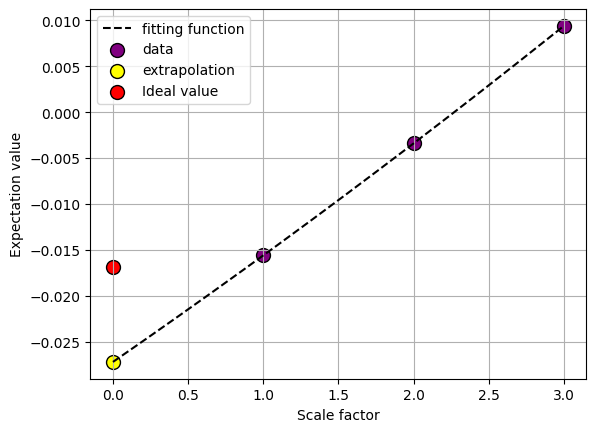

In [70]:
qubit_index =0
step_index = 3
tmp = np.linspace(0,len(scale_factors),len(scale_factors)*100+1)
plt.plot(tmp,np.polyval(extrapolated_richard_data[step_index,:,qubit_index],tmp),'--',color = 'black', label = 'fitting function')
plt.scatter(scale_factors,np.polyval(extrapolated_richard_data[step_index,:,qubit_index],scale_factors),color = 'purple', edgecolor = 'black',s = 100, label = 'data')
plt.scatter(0,extrapolated_richard_data[step_index,-1,qubit_index],color = 'yellow', edgecolor = 'black',s = 100, label = 'extrapolation')
plt.scatter(0,dat[step_index,qubit_index],color = 'red', edgecolor = 'black',s = 100, label = 'Ideal value')
plt.grid()
plt.ylabel('Expectation value')
plt.xlabel('Scale factor')
plt.legend()

#### Interpretation

We plot out the results from Batch as a demonstration of ZNE as the previous example.  

### Cost estimate

The tracker reports estimated Braket quantum-task charges for tasks created from this notebook session. Estimates can differ from final AWS billing and may not include all managed compute charges.

In [50]:
if "t" not in globals():
    print("Run the cost tracking setup cell near the top of the notebook first.")
else:
    print(
        "Note: Charges shown are estimates based on Amazon Braket simulator and QPU task usage. "
        "Estimated charges may differ from actual AWS billing and do not include every possible "
        "charge, such as managed compute used by Hybrid Jobs."
    )
    print(
        f"Estimated cost to run tracked Braket tasks: "
        f"{t.qpu_tasks_cost() + t.simulator_tasks_cost():.2f} USD"
    )

Run the cost tracking setup cell near the top of the notebook first.


## References

[1] Cai et al.,[**Quantum Error Mitigation**](https://doi.org/10.1103/RevModPhys.95.045005) (2023), Rev. Mod. Phys. 95, 045005. 

[2] [**Error Mitigation examples on AWS Bracket**](examples/braket_features/Error_Mitigation_on_Amazon_Braket.ipynb)

[3] Temme et al., [**Error Mitigation for Short-Depth Quantum Circuits**](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.119.180509) (2017), Phy. Rev. Lett., 119, 180509.

[4] Mohammadipour et al., [**Direct Analysis of Zero-Noise Extrapolation: Polynomial Methods, Error Bounds, and Simultaneous Physical-Algorithmic Error Mitigation**](https://doi.org/10.22331/q-2025-11-14-1909) (2025), 	Quantum 9, 1909.

[5] Rendon et al., [**Improved Accuracy for Trotter Simulations Using Chebyshev Interpolation**](https://doi.org/10.22331/q-2024-02-26-1266) (2024), 	Quantum 8, 1266.
